In [104]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [105]:
%pip install numpy
%pip install pandas
%pip install pytest
%pip install requests
%pip install ipywidgets
%pip install jupyter_ui_poll

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrad

## config variables

In [ ]:
email = "gyaviiraroy8@gmail.com"

## Http fundermentals

**Using urllib to get geocoding into**

In [106]:
import json
import urllib.parse
import urllib.request

base_url = "https://geocoding-api.open-meteo.com/v1/search"
time_out=10
location='kampala'

try:
    params = {"name": location, "count": 1, "language": 'en', "format": 'json'}
    url = f"{base_url}?{urllib.parse.urlencode(params)}"
    with urllib.request.urlopen(url, timeout=time_out) as resp:
        results = json.load(resp).get("results", [])
        results[0]['latitude'], results[0]['longitude']

        print("Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)\n" , f"Location:{location}\n", f"Latitude:{results[0]['latitude']}", f"Longitude:{results[0]['longitude']}")
except Exception as e:
    print(f"Error: {e}")   



Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)
 Location:kampala
 Latitude:0.31628 Longitude:32.58219


**Using Requests to get geocoding info**

In [107]:
import json
import requests

base_url = "https://geocoding-api.open-meteo.com/v1/search"
time_out=10
location='Gulu'

try:
    params = {"name": location, "count": 1, "language": 'en', "format": 'json'}
    resp = requests.get(base_url, params=params, timeout=time_out)
    resp.raise_for_status()
    results = resp.json().get("results", [])
    results[0]['latitude'], results[0]['longitude']

    print("Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)\n" , f"Location:{location}\n", f"Latitude:{results[0]['latitude']}", f"Longitude:{results[0]['longitude']}")
except Exception as e:
    print(f"Error: {e}")   

Source: Open-Meteo Geocoding (geocoding-api.open-meteo.com/v1/search)
 Location:Gulu
 Latitude:2.77457 Longitude:32.29899


## Comparing urllib and requests

| | urllib | requests |
|---|---|---|
| How much code | More. I had to build the URL myself, open it, read the response and turn it into JSON. | Less. I pass the parameters in a dictionary and call `.json()` to get the data. |
| Handling errors | It raises different errors for different problems (`HTTPError` for a bad response, `URLError` for a network problem), so I have to catch each one. | `raise_for_status()` checks for a bad response, and `requests.RequestException` catches every kind of error in one go. |
| Sending headers | I have to create a `Request` object first to add headers. | I just pass `headers={...}` to `requests.get()`. |
| Encoding | I encode the URL with `urlencode` and decode the response myself. | It encodes the URL and decodes the response for me. |
| Installing | Nothing to install. It comes with Python. | I need to install it with `pip install requests`. |

urllib works without installing anything, but I had to write more code and handle more of the details myself. requests did the same job in fewer lines and was easier to read, so I would use it unless I couldn't install extra packages.

## Status code, the Content-Type header, and the response time 

In [108]:
import requests

base_url = "https://geocoding-api.open-meteo.com/v1/search"
time_out=10
#test location is kampala
location='kampala'
try:
    params = {"name":location, "count": 1, "language": "en", "format": "json"}
    resp = requests.get(base_url, params=params, timeout=time_out)

    print("Status code:  ", resp.status_code)
    print("Content-Type: ", resp.headers["Content-Type"])
    print(f"Response time: {resp.elapsed.total_seconds() * 1000:.0f} ms")
except Exception as e:
    print(f"Error: {e}")   

Status code:   200
Content-Type:  application/json; charset=utf-8
Response time: 905 ms


## Forecast retreival and display

In [109]:
from src.open_meteo import OpenMeteo

try:
    time_out =10
    n_days = 7
    location = input('Please provide a location: ')
    if len(location) <= 0:
        raise ValueError('Invalid location name!')
       
    wf =  OpenMeteo()          
    data = wf.geocode(location, time_out)
    if(data):
        fcst= wf.get_forecast(data['latitude'],data['longitude'], n_days, data['timezone'],time_out)
        if(fcst):
            display(Markdown(
                f"**Location:** {location}, **Country:** {data.get('country', '-')}, "
                f"**Time zone:** {fcst['timezone']}"
                ))
            display(wf.forecast_to_dataframe(fcst))
        
except Exception as e:
    print(f"Error: {e}")

**Location:** kampala, **Country:** Uganda, **Time zone:** Africa/Kampala

,Weather code,Weather,Max temperature (°C),Min temperature (°C),Precipitation (mm),Max wind speed (km/h)
Date,,,,,,
2026-10-07,95,Thunderstorm,28.0,18.6,14.7,13.2
2026-10-08,81,Moderate rain showers,27.0,18.0,5.7,10.0
2026-10-09,95,Thunderstorm,25.8,19.0,28.7,11.2
2026-10-10,81,Moderate rain showers,25.8,19.0,5.3,13.9
2026-10-11,95,Thunderstorm,24.8,18.2,21.9,12.2
2026-10-12,80,Slight rain showers,25.0,18.0,15.0,10.1
2026-10-13,80,Slight rain showers,25.6,18.4,6.5,15.7


## Report and summary

**Location:** kampala, **Country:** Uganda, **Time zone:** Africa/Kampala

**7-day forecast for kampala**
**From 07 Oct To 13 Oct 2026**

| Measure | Day | Value |
|---|---|---|
| Average daytime high | - | 26.0 °C |
| Average night-time low | - | 18.5 °C |
| Warmest day | Wed 07 Oct | 28.0 °C |
| Coldest day | Sun 11 Oct | 24.8 °C |
| Coolest night | Thu 08 Oct | 18.0 °C |
| Total rain | - | 97.8 mm |
| Rainy days (1 mm or more) | - | 7 of 7 |
| Wettest day | Fri 09 Oct | 28.7 mm |
| Driest day | Sat 10 Oct | 5.3 mm |
| Windiest day | Tue 13 Oct | 15.7 km/h |
| Most common conditions | - | Thunderstorm |

,Weather,Max temperature (°C),Min temperature (°C),Precipitation (mm),Max wind speed (km/h)
Date,,,,,
Wed 07 Oct,Thunderstorm,28.0,18.6,14.7,13.2
Thu 08 Oct,Moderate rain showers,27.0,18.0,5.7,10.0
Fri 09 Oct,Thunderstorm,25.8,19.0,28.7,11.2
Sat 10 Oct,Moderate rain showers,25.8,19.0,5.3,13.9
Sun 11 Oct,Thunderstorm,24.8,18.2,21.9,12.2
Mon 12 Oct,Slight rain showers,25.0,18.0,15.0,10.1
Tue 13 Oct,Slight rain showers,25.6,18.4,6.5,15.7


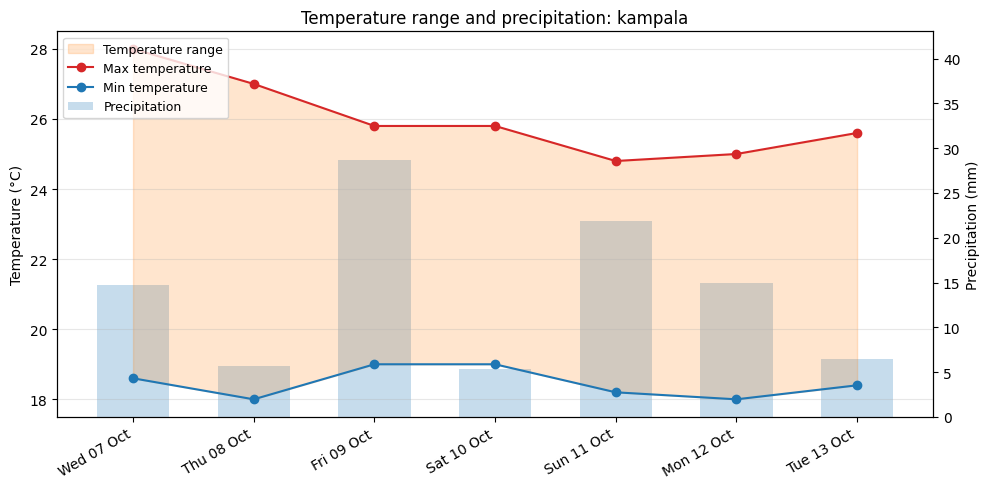

In [113]:
from src.open_meteo import OpenMeteo
from src.weather_report import WeatherReport

try:
    time_out =10
    n_days = 7
    location = input('Please provide a location: ')
    if len(location) <= 0:
        raise ValueError('Invalid location name!')
       
    wf =   OpenMeteo()          
    data = wf.geocode(location, time_out)
    if(data):
        fcst= wf.get_forecast(data['latitude'],data['longitude'], n_days,data['timezone'],time_out)
        if(fcst):
            dataframe =  wf.forecast_to_dataframe(fcst)
            display(Markdown( 
                    f"**Location:** {location}, **Country:** {data.get('country', '-')}, "
                    f"**Time zone:** {fcst['timezone']}"
                    ))
            report = WeatherReport(dataframe, location)
            report.show()
            
except Exception as e:
    print(f"Error: {e}")

## Robustness testing

In [112]:
import time
import requests
from unittest.mock import patch

from src.open_meteo import OpenMeteo

weather = OpenMeteo()

def run_case(title, func):
    """Run one test case and report the outcome instead of stopping the notebook."""
    print(f"=== {title} ===")
    start = time.perf_counter()
    try:
        result = func()
        print("Result:   no error (unexpected)", result)
    except Exception as e:
        print(f"Raised:   {type(e).__name__}")
        print(f"Message:  {e}")
        if e.__cause__ is not None:
            print(f"Cause:    {type(e.__cause__).__name__}")
    print(f"Time:     {time.perf_counter() - start:.2f} s\n")


# scenario 1. Invalid city
run_case("Invalid city",
         lambda: weather.geocode("Xyzzyqwertyville"))

# scenario 2. Invalid latitude
run_case("Invalid latitude (999)",
         lambda: weather.get_forecast(999, 32.58219))

#scenario 3. No network (simulated): every request raises ConnectionError.
#workflow: we alter run time request to fake connectivity issue
with patch("src.weather_forecast.requests.get", side_effect=requests.ConnectionError("Network is unreachable")) as fake_get, patch("src.weather_forecast.time.sleep") as fake_sleep:
    run_case("No network (simulated)", lambda: weather.get_forecast(0.31628, 32.58219))
    print(f"Attempts made:  {fake_get.call_count}")
    print(f"Backoff delays: {[c.args[0] for c in fake_sleep.call_args_list]} s\n")

#scenario 4. Tiny timeout: no real server can answer in 1 millisecond.
run_case("Tiny timeout (0.001 s)",
         lambda: weather.get_forecast(0.31628, 32.58219, time_out=0.001))

=== Invalid city ===
Raised:   ValueError
Message:  No results found for 'Xyzzyqwertyville'
Time:     0.95 s

=== Invalid latitude (999) ===
Raised:   HttpRequestException
Message:  Request Failed: Connection to https://api.open-meteo.com/v1/forecast failed after 1 attempt(s): HTTP 400 Bad Request
Cause:    HTTPError
Time:     0.93 s

=== No network (simulated) ===
Raised:   HttpRequestException
Message:  Request Failed: Connection to https://api.open-meteo.com/v1/forecast failed after 4 attempt(s): could not connect (Network is unreachable)
Cause:    ConnectionError
Time:     0.00 s

Attempts made:  4
Backoff delays: [1.0, 2.0, 4.0] s

=== Tiny timeout (0.001 s) ===
Raised:   HttpRequestException
Message:  Request Failed: Connection to https://api.open-meteo.com/v1/forecast failed after 4 attempt(s): timed out after 0.001 s
Cause:    ConnectTimeout
Time:     7.05 s



## Second source usage (Met Norway)

**Location:** kampala, **Country:** Uganda, **Time zone:** Africa/Kampala

**7-day forecast for kampala**
**From 07 Oct To 13 Oct 2026**

| Measure | Day | Value |
|---|---|---|
| Average daytime high | - | 24.5 °C |
| Average night-time low | - | 19.3 °C |
| Warmest day | Thu 08 Oct | 26.9 °C |
| Coldest day | Wed 07 Oct | 21.5 °C |
| Coolest night | Thu 08 Oct | 18.2 °C |
| Total rain | - | 110.6 mm |
| Rainy days (1 mm or more) | - | 6 of 7 |
| Wettest day | Mon 12 Oct | 32.9 mm |
| Driest day | Wed 07 Oct | 0.0 mm |
| Windiest day | Thu 08 Oct | 5.3 m/s |
| Most common conditions | - | Partly cloudy |

,Weather,Max temperature (°C),Min temperature (°C),Precipitation (mm),Max wind speed (m/s)
Date,,,,,
Wed 07 Oct,Fair,21.5,21.2,0.0,1.4
Thu 08 Oct,Partly cloudy,26.9,18.2,6.2,5.3
Fri 09 Oct,Partly cloudy,25.7,19.1,29.0,3.9
Sat 10 Oct,Partly cloudy,25.7,19.5,10.6,4.3
Sun 11 Oct,Heavy rain,23.6,19.4,24.1,3.3
Mon 12 Oct,Rain,22.4,19.2,32.9,1.5
Tue 13 Oct,Cloudy,25.6,18.4,7.8,3.8


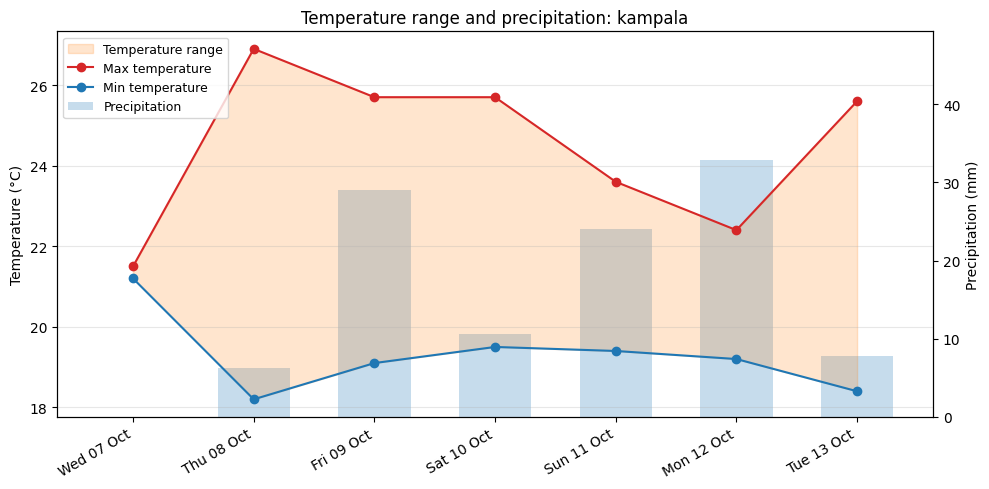

In [ ]:
from src.met_norway import MetNorway
from src.weather_report import WeatherReport

try:
    time_out =10
    n_days = 7
    location = input('Please provide a location: ')
    if len(location) <= 0:
        raise ValueError('Invalid location name!')
       
    wf =   MetNorway()          
    data = wf.geocode(location, time_out)
    if(data):
        fcst= wf.get_forecast(data['latitude'],data['longitude'], email, n_days, data['timezone'],time_out)
        if(fcst):
            dataframe =  wf.forecast_to_dataframe(fcst)
            display(Markdown( 
                    f"**Location:** {location}, **Country:** {data.get('country', '-')}, "
                    f"**Time zone:** {fcst['timezone']}"
                    ))
            report = WeatherReport(dataframe, location)
            report.show()
            
except Exception as e:
    print(f"Error: {e}")